In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn 
import torch 
import tensorflow as tf



In [6]:
from astropy.io import fits

In [7]:
hdul = fits.open("gll_psc_v35.fit")


In [8]:
data = hdul[1].data
datadup = data
DataDict = {}
for name in data.names:
    if len(data[name].shape) == 1:
        DataDict[name]=data[name]

df = pd.DataFrame(DataDict)


In [9]:
df['Conf_68_SemiMajor']

0       0.032378
1       0.094544
2       0.051373
3       0.036880
4       0.018440
          ...   
7190    0.024607
7191    0.136728
7192    0.130685
7193    0.050757
7194    0.018934
Name: Conf_68_SemiMajor, Length: 7195, dtype: float32

## single dimension columns and there context to the dataset
### Table:

# Fermi 4FGL Dataset Feature Documentation

| Column                | Full Form / Meaning                      | Physical Interpretation                 | ML Relevance                     | Recommendation |
| --------------------- | ---------------------------------------- | --------------------------------------- | -------------------------------- | -------------- |
| Source_Name           | Source Identifier                        | Unique source name in catalog           | No physical information          | Drop           |
| DataRelease           | Catalog Release Version                  | Release version of source entry         | No physical information          | Drop           |
| RAJ2000               | Right Ascension (J2000)                  | Celestial longitude                     | Sky location                     | Optional       |
| DEJ2000               | Declination (J2000)                      | Celestial latitude                      | Sky location                     | Optional       |
| GLON                  | Galactic Longitude                       | Position relative to Milky Way          | Pulsars cluster in galaxy        | Keep           |
| GLAT                  | Galactic Latitude                        | Distance from galactic plane            | Strong pulsar indicator          | Keep           |
| Conf_68_SemiMajor     | 68% Confidence Semi-Major Axis           | Position uncertainty                    | Weakly informative               | Optional       |
| Conf_68_SemiMinor     | 68% Confidence Semi-Minor Axis           | Position uncertainty                    | Weakly informative               | Optional       |
| Conf_68_PosAng        | 68% Confidence Position Angle            | Orientation of uncertainty ellipse      | Weak feature                     | Drop           |
| Conf_95_SemiMajor     | 95% Confidence Semi-Major Axis           | Position uncertainty                    | Weak feature                     | Optional       |
| Conf_95_SemiMinor     | 95% Confidence Semi-Minor Axis           | Position uncertainty                    | Weak feature                     | Optional       |
| Conf_95_PosAng        | 95% Confidence Position Angle            | Orientation of uncertainty ellipse      | Weak feature                     | Drop           |
| ROI_num               | Region Of Interest Number                | Sky analysis region                     | Technical metadata               | Drop           |
| Extended_Source_Name  | Extended Source Identifier               | Name of associated extended object      | Data leakage risk                | Drop           |
| Signif_Avg            | Average Detection Significance           | Confidence source exists                | Strong signal quality metric     | Keep           |
| Pivot_Energy          | Pivot Energy                             | Reference energy minimizing uncertainty | Spectral characteristic          | Keep           |
| Flux1000              | Flux Above 1 GeV                         | Photon brightness                       | Strong physical feature          | Keep           |
| Unc_Flux1000          | Flux1000 Uncertainty                     | Measurement error                       | Optional                         | Optional       |
| Energy_Flux100        | Energy Flux Above 100 MeV                | Total received energy                   | Strong physical feature          | Keep           |
| Unc_Energy_Flux100    | Energy Flux Uncertainty                  | Measurement error                       | Optional                         | Optional       |
| SpectrumType          | Spectral Model Type                      | PowerLaw, LogParabola, etc.             | Strong categorical feature       | One-Hot Encode |
| PL_Flux_Density       | Power Law Flux Density                   | Brightness under power-law fit          | Useful spectral feature          | Keep           |
| Unc_PL_Flux_Density   | Flux Density Uncertainty                 | Error estimate                          | Optional                         | Optional       |
| PL_Index              | Power Law Spectral Index                 | Spectrum slope                          | Important discriminator          | Keep           |
| Unc_PL_Index          | PL Index Uncertainty                     | Error estimate                          | Optional                         | Optional       |
| LP_Flux_Density       | Log-Parabola Flux Density                | Brightness under curved fit             | Useful feature                   | Keep           |
| Unc_LP_Flux_Density   | LP Flux Uncertainty                      | Error estimate                          | Optional                         | Optional       |
| LP_Index              | Log-Parabola Index                       | Spectral slope                          | Useful feature                   | Keep           |
| Unc_LP_Index          | LP Index Uncertainty                     | Error estimate                          | Optional                         | Optional       |
| LP_beta               | Log-Parabola Curvature                   | Degree of spectral curvature            | Important pulsar feature         | Keep           |
| Unc_LP_beta           | Curvature Uncertainty                    | Error estimate                          | Optional                         | Optional       |
| LP_SigCurv            | Curvature Significance                   | Confidence spectrum is curved           | Strong feature                   | Keep           |
| LP_EPeak              | Log-Parabola Peak Energy                 | Energy of maximum emission              | Useful feature                   | Keep           |
| Unc_LP_EPeak          | Peak Energy Uncertainty                  | Error estimate                          | Optional                         | Optional       |
| PLEC_Flux_Density     | PLEC Flux Density                        | Brightness under cutoff model           | Useful feature                   | Keep           |
| Unc_PLEC_Flux_Density | Flux Density Uncertainty                 | Error estimate                          | Optional                         | Optional       |
| PLEC_IndexS           | PLEC Spectral Index                      | Spectral slope                          | Important feature                | Keep           |
| Unc_PLEC_IndexS       | Spectral Index Uncertainty               | Error estimate                          | Optional                         | Optional       |
| PLEC_ExpfactorS       | Exponential Cutoff Factor                | Cutoff strength                         | Strong pulsar indicator          | Keep           |
| Unc_PLEC_ExpfactorS   | Cutoff Uncertainty                       | Error estimate                          | Optional                         | Optional       |
| PLEC_Exp_Index        | Cutoff Exponent                          | Shape of cutoff                         | Useful feature                   | Keep           |
| Unc_PLEC_Exp_Index    | Cutoff Exponent Uncertainty              | Error estimate                          | Optional                         | Optional       |
| PLEC_SigCurv          | PLEC Curvature Significance              | Confidence cutoff exists                | Strong feature                   | Keep           |
| PLEC_EPeak            | PLEC Peak Energy                         | Peak emission energy                    | Useful feature                   | Keep           |
| Unc_PLEC_EPeak        | Peak Energy Uncertainty                  | Error estimate                          | Optional                         | Optional       |
| Npred                 | Predicted Photon Count                   | Estimated detected photons              | Brightness measure               | Keep           |
| Variability_Index     | Variability Index                        | Brightness variation over time          | Very strong AGN/Pulsar separator | Keep           |
| Frac_Variability      | Fractional Variability                   | Normalized variability                  | Strong feature                   | Keep           |
| Unc_Frac_Variability  | Variability Uncertainty                  | Error estimate                          | Optional                         | Optional       |
| Signif_Peak           | Peak Detection Significance              | Significance at brightest period        | Useful feature                   | Keep           |
| Flux_Peak             | Peak Flux                                | Maximum brightness observed             | Useful feature                   | Keep           |
| Unc_Flux_Peak         | Peak Flux Uncertainty                    | Error estimate                          | Optional                         | Optional       |
| Time_Peak             | Peak Time                                | When brightest period occurred          | Weak feature                     | Optional       |
| Peak_Interval         | Peak Duration                            | Duration of brightest period            | Potentially useful               | Optional       |
| ASSOC_4FGL            | Previous Fermi Association               | Linked known source                     | Data leakage                     | Drop           |
| ASSOC_FGL             | Older Fermi Association                  | Linked known source                     | Data leakage                     | Drop           |
| ASSOC_FHL             | High-Energy Catalog Association          | Linked known source                     | Data leakage                     | Drop           |
| ASSOC_GAM1            | Gamma Catalog Association 1              | Linked known source                     | Data leakage                     | Drop           |
| ASSOC_GAM2            | Gamma Catalog Association 2              | Linked known source                     | Data leakage                     | Drop           |
| ASSOC_GAM3            | Gamma Catalog Association 3              | Linked known source                     | Data leakage                     | Drop           |
| TEVCAT_FLAG           | TeV Catalog Flag                         | Associated with TeV detection           | Potential leakage                | Drop           |
| ASSOC_TEV             | TeV Source Association                   | Linked TeV source                       | Data leakage                     | Drop           |
| CLASS1                | Primary Source Class                     | PSR, MSP, BLL, FSRQ, etc.               | Target Label                     | Use as Target  |
| CLASS2                | Secondary Source Class                   | Additional classification               | Potential leakage                | Drop           |
| ASSOC1                | Primary Counterpart Object               | Known source association                | Data leakage                     | Drop           |
| ASSOC2                | Secondary Counterpart Object             | Known source association                | Data leakage                     | Drop           |
| ASSOC_PROB_BAY        | Bayesian Association Probability         | Confidence counterpart is correct       | Potential leakage                | Drop           |
| ASSOC_PROB_LR         | Likelihood Ratio Association Probability | Confidence counterpart is correct       | Potential leakage                | Drop           |
| RA_Counterpart        | Counterpart Right Ascension              | Position of associated object           | Leakage risk                     | Drop           |
| DEC_Counterpart       | Counterpart Declination                  | Position of associated object           | Leakage risk                     | Drop           |
| Unc_Counterpart       | Counterpart Position Uncertainty         | Measurement uncertainty                 | Weak feature                     | Drop           |
| Flags                 | Source Quality Flags                     | Warnings about source quality           | Useful for filtering data        | Optional       |

# Additional Multi-Dimensional Features

| Column           | Shape         | Meaning                                      | Recommendation                      |
| ---------------- | ------------- | -------------------------------------------- | ----------------------------------- |
| Flux_Band        | (7195, 8)     | Flux in 8 gamma-ray energy bands             | Expand into 8 features or use PCA   |
| Unc_Flux_Band    | (7195, 8, 2)  | Lower/upper uncertainty for each energy band | Flatten or drop initially           |
| nuFnu_Band       | (7195, 8)     | Spectral Energy Distribution values          | Expand into 8 features              |
| Sqrt_TS_Band     | (7195, 8)     | Detection significance per energy band       | Expand into 8 features              |
| Flux_History     | (7195, 14)    | Time-series brightness history               | Extract mean/std/min/max or use PCA |
| Unc_Flux_History | (7195, 14, 2) | Uncertainty of brightness history            | Drop initially                      |
| Sqrt_TS_History  | (7195, 14)    | Detection significance over time             | Extract summary statistics          |

# Suggested Initial Feature Set

GLON, GLAT, Signif_Avg, Pivot_Energy, Flux1000, Energy_Flux100, SpectrumType, PL_Index, LP_Index, LP_beta, LP_SigCurv, PLEC_IndexS, PLEC_ExpfactorS, PLEC_SigCurv, PLEC_EPeak, Npred, Variability_Index, Frac_Variability, Signif_Peak, Flux_Peak

# Suggested Target

```python
df["CLASS1"] = df["CLASS1"].str.strip().str.lower()

df["Is_Pulsar"] = df["CLASS1"].isin(["psr", "msp"]).astype(int)
```

Where:

* 1 = Pulsar (PSR or MSP)
* 0 = Non-Pulsar


In [10]:
#print(df.head())
print(df.CLASS1.value_counts())

CLASS1
         2423
bcu      1622
bll      1468
fsrq      776
MSP       139
unk       137
PSR       137
spp       126
rdg        47
FSRQ       44
glc        41
msp        40
SNR        26
BLL        22
snr        18
PWN        13
bin         9
pwn         9
sbg         8
HMB         8
NOV         8
agn         7
lmb         7
RDG         6
css         6
SPP         6
sey         4
gal         4
nlsy1       4
NLSY1       4
psr         4
sfr         3
hmb         3
SFR         3
UNK         3
GAL         2
LMB         2
ssrq        2
AGN         1
BCU         1
BIN         1
GC          1
Name: count, dtype: int64


In [11]:
df['CLASS1'] = df['CLASS1'].str.strip()
df['Is_Pulsar_Class'] = (
    df['CLASS1'].isin(['PSR','MSP','psr','msp'])
).astype(int)

In [12]:
drop_cols = [
    "Source_Name",
    "DataRelease",
    "Conf_68_PosAng",
    "Conf_95_PosAng",
    "ROI_num",
    "Extended_Source_Name",

    # Association / leakage columns
    "ASSOC_4FGL",
    "ASSOC_FGL",
    "ASSOC_FHL",
    "ASSOC_GAM1",
    "ASSOC_GAM2",
    "ASSOC_GAM3",
    "ASSOC_TEV",
    "ASSOC1",
    "ASSOC2",
    "ASSOC_PROB_BAY",
    "ASSOC_PROB_LR",

    # Counterpart leakage
    "RA_Counterpart",
    "DEC_Counterpart",
    "Unc_Counterpart",

    # Labels / target leakage
    "CLASS2",

    # Other
    "TEVCAT_FLAG"
]

df = df.drop(columns=drop_cols)

In [13]:
peak_cols = [
    "Signif_Peak",
    "Flux_Peak",
    "Unc_Flux_Peak",
    "Time_Peak",
    "Peak_Interval"
]

df = df.drop(columns=peak_cols)

In [14]:
df = pd.get_dummies(df, columns=["SpectrumType"])

In [15]:
print(df.isna().sum().sort_values(ascending=False).head(20))
df = df.fillna(df.median(numeric_only=True))


Unc_PLEC_Exp_Index       7161
PLEC_EPeak               2407
Unc_PLEC_EPeak           2407
Unc_LP_EPeak              904
LP_EPeak                  903
Conf_95_SemiMinor          90
Conf_68_SemiMinor          90
Conf_95_SemiMajor          90
Conf_68_SemiMajor          90
Unc_PL_Index               14
Unc_LP_beta                 5
Unc_PLEC_Flux_Density       4
PLEC_Exp_Index              4
PLEC_ExpfactorS             4
PLEC_IndexS                 4
Unc_PLEC_IndexS             4
Unc_PLEC_ExpfactorS         4
PLEC_Flux_Density           4
Unc_LP_Index                4
Unc_LP_Flux_Density         4
dtype: int64


In [16]:
X = df
X.drop( columns=[
        "CLASS1",
    ]
)
y = df["Is_Pulsar_Class"]

In [17]:

print(len(df))
print(len(X))

7195
7195


In [18]:
X = df.drop(columns=["CLASS1", "Is_Pulsar_Class"])
X = X.replace([np.inf, -np.inf], np.nan)

mask = X.notna().all(axis=1)
X = X.loc[mask]
y = df.loc[mask, "Is_Pulsar_Class"]

In [19]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [20]:
# Random Forest with SMOTE + hyperparameter search (optimize F1)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import numpy as np

pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])
param_dist = {
    'clf__n_estimators': [100, 200, 500],
    'clf__max_depth': [None, 5, 10, 20],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__class_weight': [None, 'balanced', 'balanced_subsample']
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(pipe, param_dist, n_iter=30, scoring='f1', cv=cv, n_jobs=-1, random_state=42, verbose=1)
rs.fit(X_train, y_train)
model = rs.best_estimator_
print('Best params:', rs.best_params_)
print('Best CV f1:', rs.best_score_)

# Save preds/probs for evaluation in next cell
pred = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'clf__n_estimators': 100, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__class_weight': 'balanced_subsample'}
Best CV f1: 0.894322529197014


In [21]:
print(len(df))
print(len(X))

print(df["Is_Pulsar_Class"].value_counts())
print(y.value_counts())

7195
7194
Is_Pulsar_Class
0    6875
1     320
Name: count, dtype: int64
Is_Pulsar_Class
0    6874
1     320
Name: count, dtype: int64


Balanced accuracy: 0.936409090909091

Classification report:

              precision    recall  f1-score   support

  non-pulsar       0.99      1.00      1.00      1375
      pulsar       0.95      0.88      0.91        64

    accuracy                           0.99      1439
   macro avg       0.97      0.94      0.95      1439
weighted avg       0.99      0.99      0.99      1439



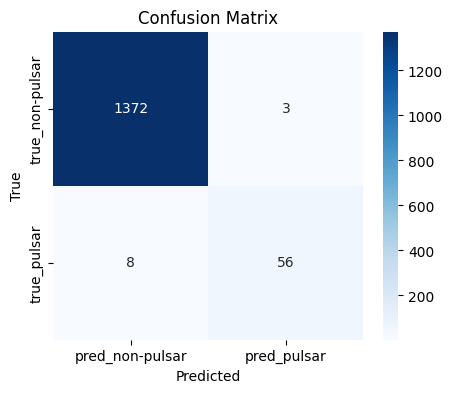

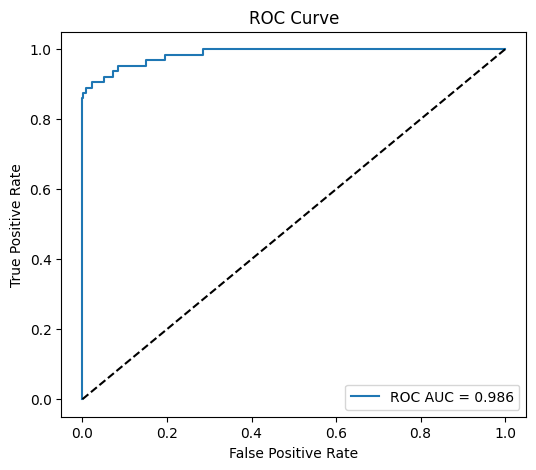

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, balanced_accuracy_score, precision_recall_curve
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Basic metrics at default 0.5 threshold
print('=== RandomForest Evaluation (Default 0.5 Threshold) ===')
print('Balanced accuracy:', balanced_accuracy_score(y_test, pred))
print('\nClassification report:')
print(classification_report(y_test, pred, target_names=['non-pulsar','pulsar']))

# Confusion matrix
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['pred_non-pulsar','pred_pulsar'],
            yticklabels=['true_non-pulsar','true_pulsar'])
plt.ylabel('True')
plt.xlabel('Predicted')
plt.title('Confusion Matrix (0.5 Threshold)')
plt.show()

# ROC AUC
try:
    auc = roc_auc_score(y_test, probs)
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'ROC AUC = {auc:.3f}')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
except Exception as e:
    print('ROC AUC not available:', e)

# Precision-Recall curve with threshold tuning
prec, rec, thr = precision_recall_curve(y_test, probs)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
best_idx = np.nanargmax(f1s)
best_thresh = thr[best_idx] if best_idx < len(thr) else 0.5
print(f'\n=== Threshold Optimization ===')
print(f'Best PR threshold: {best_thresh:.3f}, F1 = {f1s[best_idx]:.3f}')

pred_thresh = (probs >= best_thresh).astype(int)
print('\nClassification report (tuned threshold):')
print(classification_report(y_test, pred_thresh, target_names=['non-pulsar','pulsar']))

# PR curve plot
plt.figure(figsize=(8,6))
plt.plot(rec, prec, label='PR Curve')
plt.axvline(x=rec[best_idx], color='r', linestyle='--', label=f'Best F1 at threshold={best_thresh:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve with Threshold Tuning')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Feature importances
try:
    rf = model.named_steps['clf'] if hasattr(model, 'named_steps') else model
    importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    print('\n=== Top 20 Feature Importances ===')
    print(importances.head(20))
    plt.figure(figsize=(10,6))
    importances.head(20).plot(kind='bar')
    plt.title('Top 20 Feature Importances (RandomForest)')
    plt.ylabel('Importance')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Feature importances not available:', e)

# Cross-validated F1
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='f1', n_jobs=-1)
print(f'\n=== Cross-Validation ===')
print(f'CV F1 mean: {cv_scores.mean():.4f}, std: {cv_scores.std():.4f}')
print(f'Individual fold F1 scores: {[f"{s:.4f}" for s in cv_scores]}')

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# Build a pipeline and tune C with GridSearchCV
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(solver='liblinear', max_iter=5000, class_weight='balanced', random_state=42))
])
param_grid = {'clf__C': [0.01, 0.1, 1, 10]}
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='balanced_accuracy', n_jobs=-1)
grid.fit(X_train, y_train)
best_lr = grid.best_estimator_
pred_lr = best_lr.predict(X_test)
probs_lr = best_lr.predict_proba(X_test)[:, 1]
print('Best params:', grid.best_params_)
print('CV balanced accuracy:', grid.best_score_)

Best params: {'clf__C': 0.01}
CV balanced accuracy: 0.9237127553350858


Balanced accuracy: 0.9403977272727273

Classification report:

              precision    recall  f1-score   support

  non-pulsar       1.00      0.97      0.98      1375
      pulsar       0.62      0.91      0.74        64

    accuracy                           0.97      1439
   macro avg       0.81      0.94      0.86      1439
weighted avg       0.98      0.97      0.97      1439



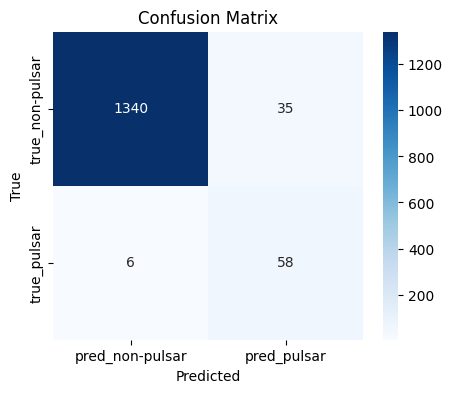

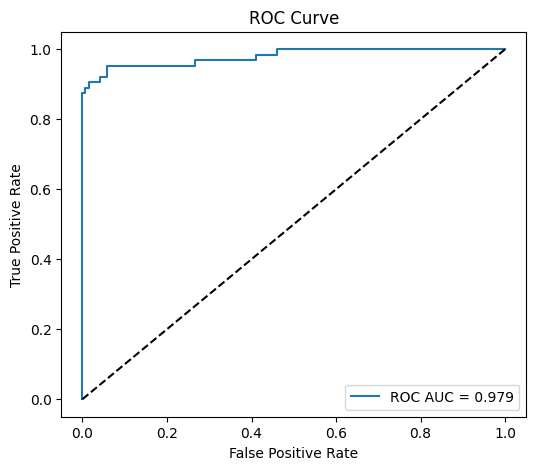

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, balanced_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluation metrics
print('Balanced accuracy:', balanced_accuracy_score(y_test, pred_lr))
print('\nClassification report:\n')
print(classification_report(y_test, pred_lr, target_names=['non-pulsar','pulsar']))

# Confusion matrix
cm = confusion_matrix(y_test, pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['pred_non-pulsar','pred_pulsar'], yticklabels=['true_non-pulsar','true_pulsar'])
plt.ylabel('True')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# ROC AUC
try:
    auc = roc_auc_score(y_test, probs_lr)
    fpr, tpr, _ = roc_curve(y_test, probs_lr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'ROC AUC = {auc:.3f}')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()
except Exception as e:
    print('ROC AUC not available:', e)

In [ ]:
df[
    ["CLASS1", "Flux_Peak", "Time_Peak"]
].head(20)

,CLASS1,Flux_Peak,Time_Peak
0,,-inf,-inf
1,,-inf,-inf
2,,-inf,-inf
3,bcu,5.738964e-09,286670016.0
4,bll,1.632524e-08,349790016.0
5,bll,-inf,-inf
6,fsrq,2.002827e-07,476030016.0
7,,-inf,-inf
8,bcu,-inf,-inf
9,bcu,-inf,-inf


In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

print(
    importance.sort_values(
        by="importance",
        ascending=False
    ).head(20)
)

                feature  importance
24           LP_SigCurv    0.089382
35         PLEC_SigCurv    0.081851
22              LP_beta    0.076643
37       Unc_PLEC_EPeak    0.057550
31      PLEC_ExpfactorS    0.053640
17         Unc_PL_Index    0.040939
39    Variability_Index    0.040430
8            Signif_Avg    0.038841
32  Unc_PLEC_ExpfactorS    0.036174
25             LP_EPeak    0.030425
4     Conf_68_SemiMajor    0.030109
38                Npred    0.028052
30      Unc_PLEC_IndexS    0.025270
36           PLEC_EPeak    0.024102
5     Conf_68_SemiMinor    0.023719
29          PLEC_IndexS    0.023580
40     Frac_Variability    0.023349
7     Conf_95_SemiMinor    0.022584
6     Conf_95_SemiMajor    0.022355
26         Unc_LP_EPeak    0.022334


In [ ]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test,pred))

[[1375    0]
 [   8   56]]


In [ ]:
X = X.drop(
    columns=[
        c for c in X.columns
        if c.startswith("SpectrumType")
    ]
)